# Bibliotekos

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import SparsePCA
from sklearn.manifold import TSNE
import umap

# Duomenų paruošimas

In [2]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [3]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.4, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 3832


<span style="color: red;">Poaibio eiluciu sk nesutampa su R!!</span>

# Normavimas 

In [ ]:
def min_max_normalization(x):
    return (x - x.min()) / (x.max() - x.min())

numeric_cols = sampled_data.select_dtypes(include=[np.number])
min_max_data = numeric_cols.apply(min_max_normalization)

categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

min_max_data.head()


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
0,0.247206,0.072011,0.363843,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173
1,0.471400,0.264423,0.538387,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939
2,0.468113,0.183477,0.029933,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344
3,0.281394,0.108729,0.622255,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767
4,0.451677,0.356796,0.538661,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030


In [5]:
full_min_max_data.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
0,0.247206,0.072011,0.363843,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173,0,all_other,0
1,0.471400,0.264423,0.538387,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939,0,all_other,1
2,0.468113,0.183477,0.029933,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344,0,all_other,0
3,0.281394,0.108729,0.622255,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767,0,all_other,0
4,0.451677,0.356796,0.538661,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030,0,all_other,0


# PCA

In [6]:
def PCA_Algorithm(data_scaled, n_comp):
    pca = PCA(n_components = n_comp)
    data_pca = pca.fit_transform(data_scaled)
    return(data_pca, pca.explained_variance_ratio_)

In [7]:
PCA_transformed_data, PCA_variance_data = PCA_Algorithm(min_max_data, n_comp=2)
PCA_variance_data_proc = np.round(PCA_variance_data * 100, decimals = 1)

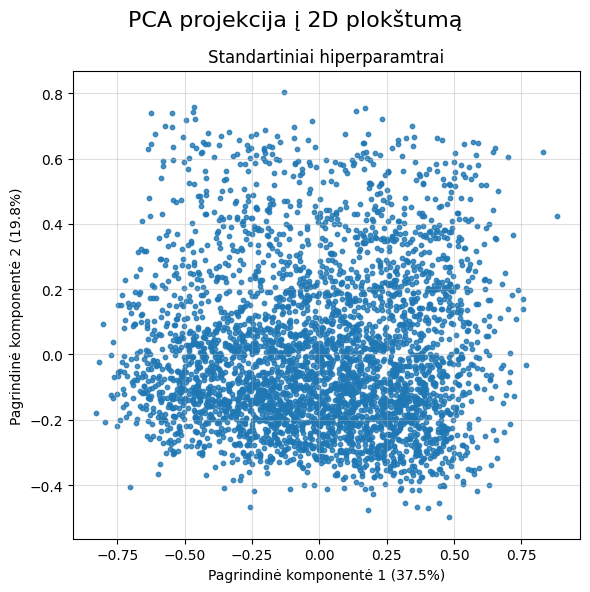

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10)
plt.title("Standartiniai hiperparamtrai")
plt.xlabel(f"Pagrindinė komponentė 1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"Pagrindinė komponentė 2 ({PCA_variance_data_proc[1]}%)")
plt.grid(alpha=0.4)

plt.suptitle("PCA projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

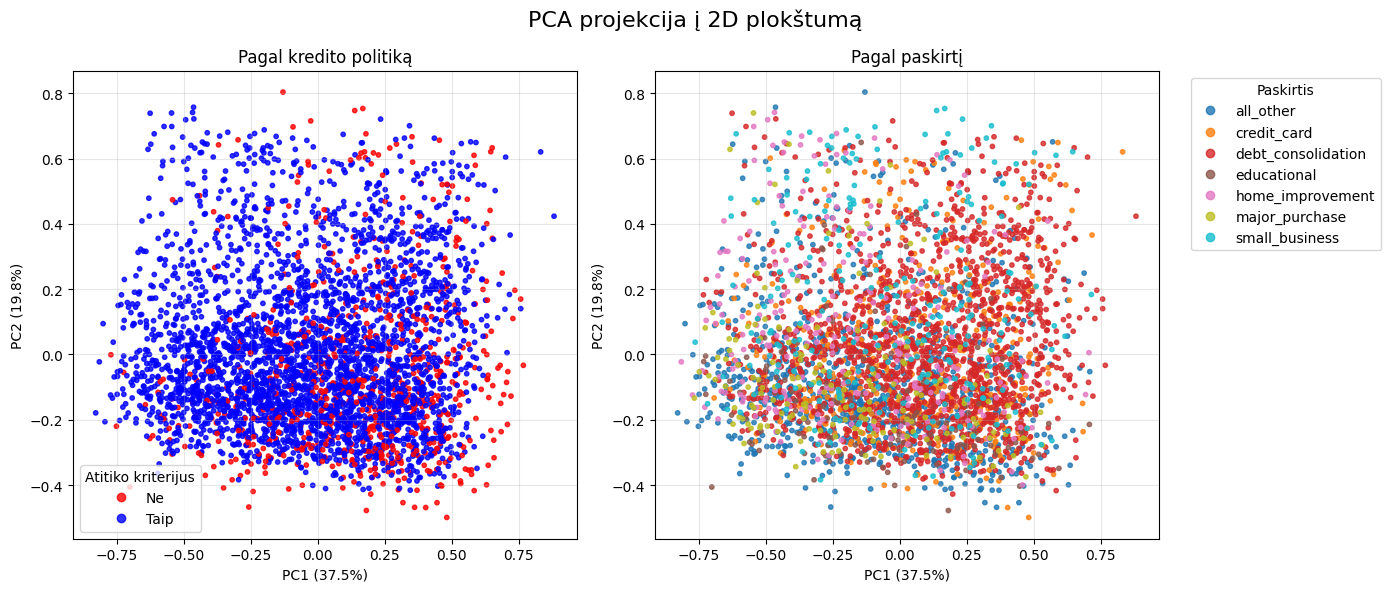

In [9]:
credit_policy = full_min_max_data['credit.policy']
purpose_codes = full_min_max_data['purpose'].astype('category').cat.codes
cmap_credit = ListedColormap(['red', 'blue'])
num_purposes = len(full_min_max_data['purpose'].unique())
cmap_purpose = plt.get_cmap('tab10', num_purposes)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10, c=credit_policy, cmap=cmap_credit)
plt.title("Pagal kredito politiką")
plt.xlabel(f"PC1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"PC2 ({PCA_variance_data_proc[1]}%)")
handles1, labels1 = scatter1.legend_elements()
plt.legend(handles1, ['Ne', 'Taip'], title="Atitiko kriterijus")
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
scatter2 = plt.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10, c=purpose_codes, cmap=cmap_purpose)
plt.title("Pagal paskirtį")
plt.xlabel(f"PC1 ({PCA_variance_data_proc[0]}%)")
plt.ylabel(f"PC2 ({PCA_variance_data_proc[1]}%)")
purpose_labels = full_min_max_data['purpose'].astype('category').cat.categories
handles2, _ = scatter2.legend_elements()
plt.legend(handles2, purpose_labels, title="Paskirtis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.suptitle("PCA projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

## PCA modifikacijos

In [10]:
kernel_pca = KernelPCA(n_components=2, kernel='rbf')
KPCA = kernel_pca.fit_transform(min_max_data)

In [11]:
sparce_pca = SparsePCA(n_components=2)
SPCA = sparce_pca.fit_transform(min_max_data)

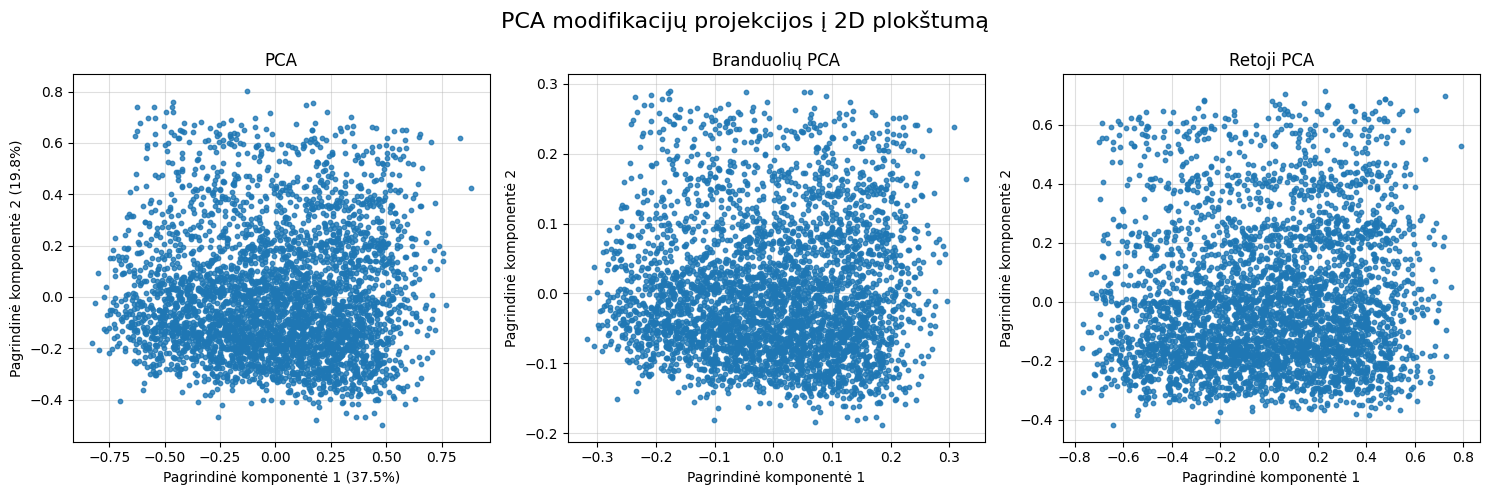

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))

ax1.scatter(PCA_transformed_data[:, 0], PCA_transformed_data[:, 1], alpha=0.8, s=10)
ax1.set_title("PCA")
ax1.set_xlabel(f"Pagrindinė komponentė 1 ({PCA_variance_data_proc[0]}%)")
ax1.set_ylabel(f"Pagrindinė komponentė 2 ({PCA_variance_data_proc[1]}%)")
ax1.grid(alpha=0.4)
ax1.set_axisbelow(True)

ax2.scatter(KPCA[:, 0], KPCA[:, 1], alpha=0.8, s=10)
ax2.set_title("Branduolių PCA")
ax2.set_xlabel(f"Pagrindinė komponentė 1")
ax2.set_ylabel(f"Pagrindinė komponentė 2")
ax2.grid(alpha=0.4)
ax2.set_axisbelow(True)

ax3.scatter(SPCA[:, 0], SPCA[:, 1], alpha=0.8, s=10)
ax3.set_title("Retoji PCA")
ax3.set_xlabel(f"Pagrindinė komponentė 1")
ax3.set_ylabel(f"Pagrindinė komponentė 2")
ax3.grid(alpha=0.4)
ax3.set_axisbelow(True)

plt.suptitle("PCA modifikacijų projekcijos į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

# t-SNE

In [13]:
tsne = TSNE(n_components=2, random_state=42)
tsne_transformed_data = tsne.fit_transform(min_max_data)

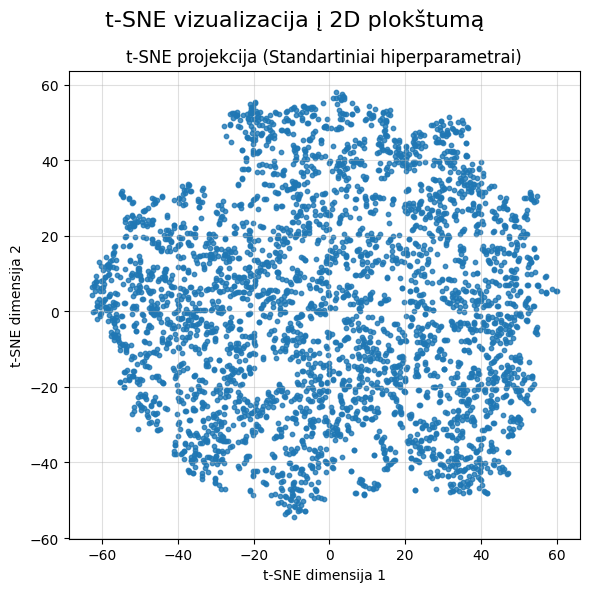

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(tsne_transformed_data[:, 0], tsne_transformed_data[:, 1], alpha=0.8, s=10)

plt.title("t-SNE projekcija (Standartiniai hiperparametrai)")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")
plt.grid(alpha=0.4)

plt.suptitle("t-SNE vizualizacija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

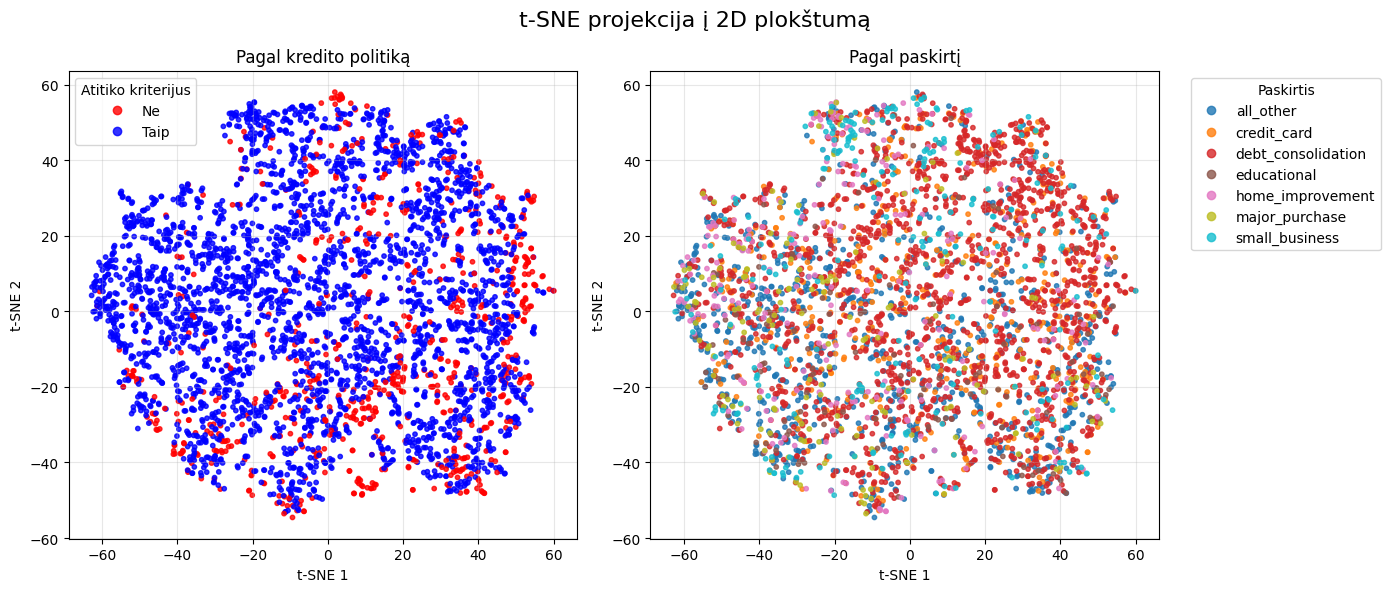

In [15]:
credit_policy = full_min_max_data['credit.policy']
purpose_codes = full_min_max_data['purpose'].astype('category').cat.codes
cmap_credit = ListedColormap(['red', 'blue'])
num_purposes = len(full_min_max_data['purpose'].unique())
cmap_purpose = plt.get_cmap('tab10', num_purposes)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(tsne_transformed_data[:, 0], tsne_transformed_data[:, 1], alpha=0.8, s=10, c=credit_policy, cmap=cmap_credit)
plt.title("Pagal kredito politiką")
plt.xlabel(f"t-SNE 1")
plt.ylabel(f"t-SNE 2")
handles1, labels1 = scatter1.legend_elements()
plt.legend(handles1, ['Ne', 'Taip'], title="Atitiko kriterijus")
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
scatter2 = plt.scatter(tsne_transformed_data[:, 0], tsne_transformed_data[:, 1], alpha=0.8, s=10, c=purpose_codes, cmap=cmap_purpose)
plt.title("Pagal paskirtį")
plt.xlabel(f"t-SNE 1")
plt.ylabel(f"t-SNE 2")
purpose_labels = full_min_max_data['purpose'].astype('category').cat.categories
handles2, _ = scatter2.legend_elements()
plt.legend(handles2, purpose_labels, title="Paskirtis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.suptitle("t-SNE projekcija į 2D plokštumą", fontsize=16)
plt.tight_layout()
plt.show()

# UMAP

In [30]:
data_umap = umap.UMAP(n_neighbors=50, min_dist=0.3, metric="euclidean", n_epochs=300, learning_rate=0.1).fit_transform(full_min_max_data.select_dtypes(include=[np.number]))

Text(0.5, 1.0, 'UMAP projekcija')

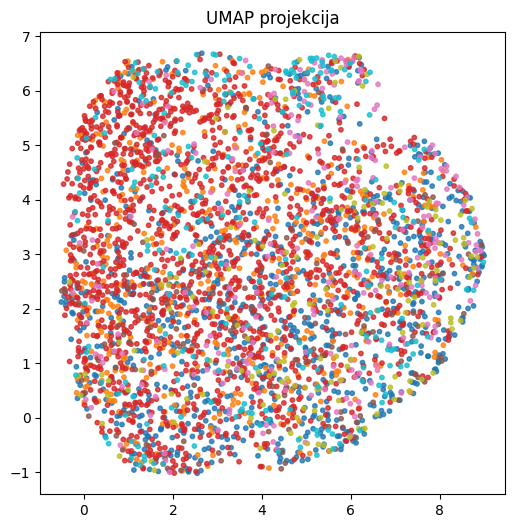

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(data_umap[:, 0], data_umap[:, 1], alpha=0.8, s=10, c=purpose_codes, cmap=cmap_purpose)
plt.title("UMAP projekcija")

Text(0.5, 1.0, 'UMAP projekcija')

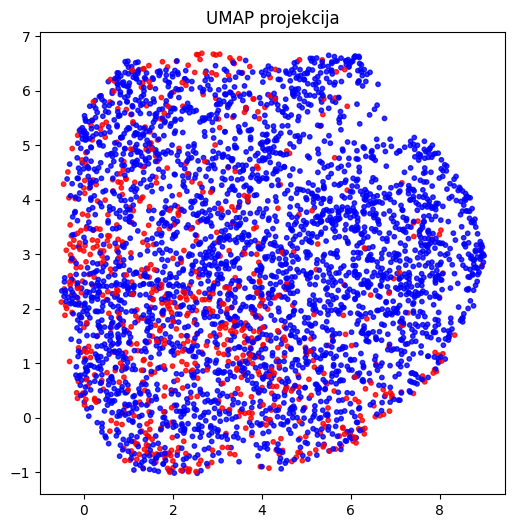

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(data_umap[:, 0], data_umap[:, 1], alpha=0.8, s=10, c=credit_policy, cmap=cmap_credit)
plt.title("UMAP projekcija")